### End of Distribution Imputation

In this technique we fill the values based on the condition 
1. Case_1 :- if our data (feature) is normally distributed then we replace the missing value with the *(mean +/- 3 S.D)*
2. Case_2 :- if our data is skewed then we replace the missing value with the help of *(Q1 -/+ 1.5 IQR)* where *IQR=(Q3(75 percentile) - Q1(25 percentile))*

3. **When to Use** when our data is not missing at the random

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('titanic_toy.csv')
df.sample(7)

,Age,Fare,Family,Survived
545,64.0,26.0000,0,0
474,22.0,9.8375,0,0
807,18.0,7.7750,0,0
253,30.0,16.1000,1,0
763,36.0,NaN,3,1
531,NaN,7.2292,0,0
99,34.0,26.0000,1,0


In [4]:
df.isna().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [5]:
df.describe()

,Age,Fare,Family,Survived
count,714.000000,846.000000,891.000000,891.000000
mean,29.699118,32.279338,0.904602,0.383838
std,14.526497,50.305796,1.613459,0.486592
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.895800,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.206250,1.000000,1.000000
max,80.000000,512.329200,10.000000,1.000000


In [6]:
df['Age'].skew()

np.float64(0.38910778230082704)

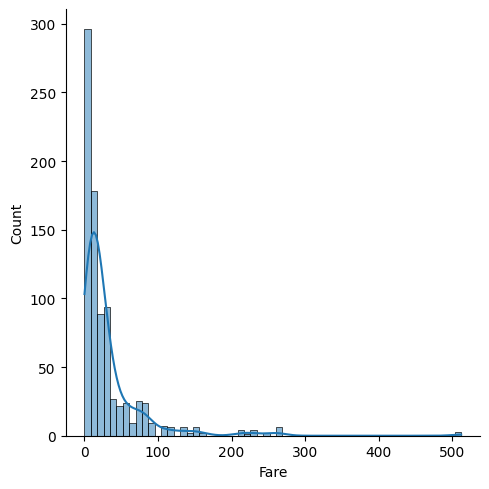

In [10]:
sns.displot(df['Fare'],kde=True)

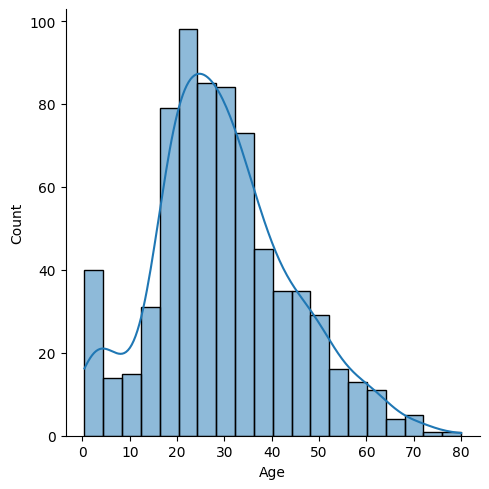

In [9]:
sns.displot(df['Age'],kde=True)

In [17]:
Age_mean = df['Age'].mean()
Age_sd = df['Age'].std()
fare_mean = df['Fare'].mean()
fare_sd = df['Fare'].std()

Age_value1 = Age_mean - 3*Age_sd
Age_value2 = Age_mean + 3*Age_sd

In our data age is nearly normally distributed and fare is skewed so
1. Age :- we replace the missing value of age with the 1st formula 
2. Fare :- we replace th missing value of fare with the 2nd formula 

In [ ]:
IQR = df['Fare'].quantile(0.75) - df['Fare'].quantile(0.25)
IQR
Fare_value_1 = df['Fare'].quantile(0.25) - 1.5 * IQR
Fare_value_2 = df['Fare'].quantile(0.75) + 1.5 * IQR


np.float64(66.17192499999999)

In [ ]:
df['Age_filled']

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [18]:
df['Age_filled'] = df['Age'].fillna(Age_value1)
df['Fare_filled'] = df['Fare'].fillna(Fare_value_1)

In [24]:
df['Age_filled2'] = df['Age'].fillna(Age_value2)
df['Fare_filled2'] = df['Fare'].fillna(Fare_value_2)

In [26]:
df.sample(10)

,Age,Fare,Family,Survived,Age_filled,Fare_filled,Age_filled2,Fare_filled2
855,18.0,9.3500,1,1,18.000000,9.350000,18.00000,9.350000
374,3.0,21.0750,4,0,3.000000,21.075000,3.00000,21.075000
764,16.0,7.7750,0,0,16.000000,7.775000,16.00000,7.775000
82,NaN,NaN,0,1,-13.880374,-27.069875,73.27861,66.171925
688,18.0,7.7958,0,0,18.000000,7.795800,18.00000,7.795800
50,7.0,39.6875,5,0,7.000000,39.687500,7.00000,39.687500
692,NaN,56.4958,0,1,-13.880374,56.495800,73.27861,56.495800
199,24.0,13.0000,0,0,24.000000,13.000000,24.00000,13.000000
399,28.0,12.6500,0,1,28.000000,12.650000,28.00000,12.650000
52,49.0,76.7292,1,1,49.000000,76.729200,49.00000,76.729200


In [28]:
df.corr()

,Age,Fare,Family,Survived,Age_filled,Fare_filled,Age_filled2,Fare_filled2
Age,1.000000,0.099481,-0.301914,-0.077221,1.000000,0.091678,1.000000,0.097698
Fare,0.099481,1.000000,0.212626,0.263920,0.134516,1.000000,-0.021228,1.000000
Family,-0.301914,0.212626,1.000000,0.016639,-0.109485,0.203992,-0.188054,0.206432
Survived,-0.077221,0.263920,0.016639,1.000000,0.032061,0.235097,-0.115641,0.261015
Age_filled,1.000000,0.134516,-0.109485,0.032061,1.000000,0.118328,-0.283253,0.135570
Fare_filled,0.091678,1.000000,0.203992,0.235097,0.118328,1.000000,-0.013649,0.917251
Age_filled2,1.000000,-0.021228,-0.188054,-0.115641,-0.283253,-0.013649,1.000000,-0.024360
Fare_filled2,0.097698,1.000000,0.206432,0.261015,0.135570,0.917251,-0.024360,1.000000
